# 61 - SigLIP 2 モデル評価（ベースライン）

## 概要
SigLIP 2 モデルを評価し、SigLIP 1 および CLIP-L との比較を行う。

## SigLIP 2 の改善点
- **トークナイザー**: Unigram (32K) → Gemma BPE (256K) — 多言語対応改善
- **訓練手法**: Sigmoid loss + デコーダ + 自己蒸留 + マスク予測
- **多言語対応**: WebLI データセット（109言語）で訓練

## モデル情報
- **Model**: google/siglip2-base-patch16-224
- **Embedding dimension**: 768
- **Type**: Multimodal (Image + Text)

## 評価指標
- シルエットスコア (2D/3D) - クラスタ分離度
- Trustworthiness (2D/3D) - 近傍関係の保持度
- カテゴリ内/間距離比 (2D/3D) - 分離の良さ
- PCAの累積寄与率

## 比較対象（既存結果）
| モデル | シルエット(2D) | Trustworthiness(2D) | 距離比(2D) |
|--------|--------------|---------------------|------------|
| SigLIP 1 | 0.174 | 0.953 | 0.455 |
| CLIP-L | 0.221 | 0.966 | 0.422 |

In [1]:
import time
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

from image_vector_poc import SigLIP2Embedder
from image_vector_poc.evaluation import EvaluationReporter, evaluate_embeddings

## 設定

In [2]:
# パス設定
DB_PATH = Path("../data/images.duckdb")
OUTPUT_DIR = Path("../data/evaluations")

# バッチサイズ（GPUメモリに応じて調整）
BATCH_SIZE = 32

# 再現性のためのランダムシード
RANDOM_STATE = 42

## 画像カタログの読み込み

In [3]:
# データベースから画像カタログを読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

query = """
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY category, file_name
"""
catalog = conn.execute(query).fetchall()
conn.close()

# データの整理
image_ids = [r[0] for r in catalog]
file_paths = [r[1] for r in catalog]
categories = [r[2] for r in catalog]
file_names = [r[3] for r in catalog]

# カテゴリ情報
category_labels = np.array(categories)
category_counts = pd.Series(categories).value_counts().to_dict()
unique_categories = list(category_counts.keys())

print(f"Total images: {len(catalog)}")
print(f"Categories: {unique_categories}")
print(f"\nCategory counts:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total images: 378
Categories: ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima', 'KashiwaVillagePark2026', 'TokyoNight202505', 'terada']

Category counts:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


## モデルの初期化

In [4]:
print("Loading SigLIP 2 model...")
embedder = SigLIP2Embedder(device="cuda")
print(f"Model: {embedder.model_name}")
print(f"Embedding dimension: {embedder.embedding_dim}")
print(f"Device: {embedder.device}")

Loading SigLIP 2 model...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model: google/siglip2-base-patch16-224
Embedding dimension: 768
Device: cuda


## 画像のベクトル化

In [5]:
print(f"Generating embeddings for {len(file_paths)} images...")
print(f"Batch size: {BATCH_SIZE}")

start_time = time.time()
embeddings_list = []

for i in tqdm(range(0, len(file_paths), BATCH_SIZE), desc="Embedding"):
    batch_paths = file_paths[i:i + BATCH_SIZE]
    
    # 画像を読み込み
    batch_images = []
    for path in batch_paths:
        try:
            img = Image.open(path).convert("RGB")
            batch_images.append(img)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            # エラー時はダミー画像を使用
            batch_images.append(Image.new("RGB", (224, 224), color="gray"))
    
    # バッチでベクトル化
    batch_embs = embedder.embed_images(batch_images)
    embeddings_list.append(batch_embs)

embeddings = np.vstack(embeddings_list)
processing_time = time.time() - start_time

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Processing time: {processing_time:.2f}s")
print(f"Speed: {len(file_paths) / processing_time:.1f} images/sec")

Generating embeddings for 378 images...
Batch size: 32


Embedding:   0%|          | 0/12 [00:00<?, ?it/s]


Embeddings shape: (378, 768)
Processing time: 91.27s
Speed: 4.1 images/sec


## 評価の実行

In [6]:
print("Running evaluation...")
print("This may take a few minutes (t-SNE computation)...\n")

metrics = evaluate_embeddings(
    embeddings=embeddings,
    labels=category_labels,
    model_name=embedder.model_name,
    embedding_dim=embedder.embedding_dim,
    categories=unique_categories,
    category_counts=category_counts,
    processing_time=processing_time,
    random_state=RANDOM_STATE,
)

Running evaluation...
This may take a few minutes (t-SNE computation)...



## 結果の表示

In [7]:
print("=" * 60)
print("Evaluation Results: SigLIP 2")
print("=" * 60)
print(f"Model: {metrics.model_name}")
print(f"Embedding dimension: {metrics.embedding_dim}")
print(f"Total images: {metrics.total_images}")
print(f"Processing time: {metrics.processing_time_seconds:.2f}s")

print("\n--- t-SNE Metrics ---")
print(f"\n2D Metrics:")
print(f"  Silhouette score: {metrics.silhouette_2d:.4f}")
print(f"  Trustworthiness:  {metrics.trustworthiness_2d:.4f}")
print(f"  Distance ratio:   {metrics.distance_ratio_2d:.4f}")

print(f"\n3D Metrics:")
print(f"  Silhouette score: {metrics.silhouette_3d:.4f}")
print(f"  Trustworthiness:  {metrics.trustworthiness_3d:.4f}")
print(f"  Distance ratio:   {metrics.distance_ratio_3d:.4f}")

print("\n--- PCA Metrics ---")
print(f"\n2D Metrics:")
print(f"  Silhouette score:  {metrics.pca_silhouette_2d:.4f}")
print(f"  Variance ratio:    {metrics.pca_variance_ratio_2d:.4f}")

print(f"\n3D Metrics:")
print(f"  Silhouette score:  {metrics.pca_silhouette_3d:.4f}")
print(f"  Variance ratio:    {metrics.pca_variance_ratio_3d:.4f}")

Evaluation Results: SigLIP 2
Model: google/siglip2-base-patch16-224
Embedding dimension: 768
Total images: 378
Processing time: 91.27s

--- t-SNE Metrics ---

2D Metrics:
  Silhouette score: 0.1560
  Trustworthiness:  0.9584
  Distance ratio:   0.4698

3D Metrics:
  Silhouette score: 0.1283
  Trustworthiness:  0.9673
  Distance ratio:   0.6033

--- PCA Metrics ---

2D Metrics:
  Silhouette score:  0.1084
  Variance ratio:    0.2662

3D Metrics:
  Silhouette score:  0.1280
  Variance ratio:    0.3196


## SigLIP 1 / CLIP-L との比較

In [8]:
import matplotlib.pyplot as plt

# 既存モデルの結果（Notebook 11, 12 より）
comparison = {
    "SigLIP 1": {
        "silhouette_2d": 0.1741, "trustworthiness_2d": 0.9533,
        "distance_ratio_2d": 0.4549, "pca_variance_2d": 0.2448,
        "silhouette_3d": 0.1035, "trustworthiness_3d": 0.9631,
        "distance_ratio_3d": 0.6445, "speed": 4.1,
    },
    "CLIP-L": {
        "silhouette_2d": 0.2210, "trustworthiness_2d": 0.9659,
        "distance_ratio_2d": 0.4215, "pca_variance_2d": 0.2587,
        "silhouette_3d": 0.1384, "trustworthiness_3d": 0.9714,
        "distance_ratio_3d": 0.6206, "speed": 4.0,
    },
    "SigLIP 2": {
        "silhouette_2d": metrics.silhouette_2d, "trustworthiness_2d": metrics.trustworthiness_2d,
        "distance_ratio_2d": metrics.distance_ratio_2d, "pca_variance_2d": metrics.pca_variance_ratio_2d,
        "silhouette_3d": metrics.silhouette_3d, "trustworthiness_3d": metrics.trustworthiness_3d,
        "distance_ratio_3d": metrics.distance_ratio_3d, "speed": len(file_paths) / processing_time,
    },
}

# 比較テーブル
print("=" * 80)
print("モデル比較: SigLIP 2 vs SigLIP 1 vs CLIP-L")
print("=" * 80)

print(f"\n{'指標':<25} {'SigLIP 1':>12} {'CLIP-L':>12} {'SigLIP 2':>12} {'SigLIP2 vs 1':>14}")
print("-" * 77)

metric_names = [
    ("シルエット(2D)", "silhouette_2d"),
    ("Trustworthiness(2D)", "trustworthiness_2d"),
    ("距離比(2D)", "distance_ratio_2d"),
    ("PCA寄与率(2D)", "pca_variance_2d"),
    ("シルエット(3D)", "silhouette_3d"),
    ("Trustworthiness(3D)", "trustworthiness_3d"),
    ("距離比(3D)", "distance_ratio_3d"),
    ("処理速度(img/s)", "speed"),
]

for display_name, key in metric_names:
    s1 = comparison["SigLIP 1"][key]
    cl = comparison["CLIP-L"][key]
    s2 = comparison["SigLIP 2"][key]
    diff = s2 - s1
    sign = "+" if diff > 0 else ""
    print(f"{display_name:<25} {s1:>12.4f} {cl:>12.4f} {s2:>12.4f} {sign}{diff:>13.4f}")

モデル比較: SigLIP 2 vs SigLIP 1 vs CLIP-L

指標                            SigLIP 1       CLIP-L     SigLIP 2   SigLIP2 vs 1
-----------------------------------------------------------------------------
シルエット(2D)                       0.1741       0.2210       0.1560       -0.0181
Trustworthiness(2D)             0.9533       0.9659       0.9584 +       0.0051
距離比(2D)                         0.4549       0.4215       0.4698 +       0.0149
PCA寄与率(2D)                      0.2448       0.2587       0.2662 +       0.0214
シルエット(3D)                       0.1035       0.1384       0.1283 +       0.0248
Trustworthiness(3D)             0.9631       0.9714       0.9673 +       0.0042
距離比(3D)                         0.6445       0.6206       0.6033       -0.0412
処理速度(img/s)                     4.1000       4.0000       4.1416 +       0.0416


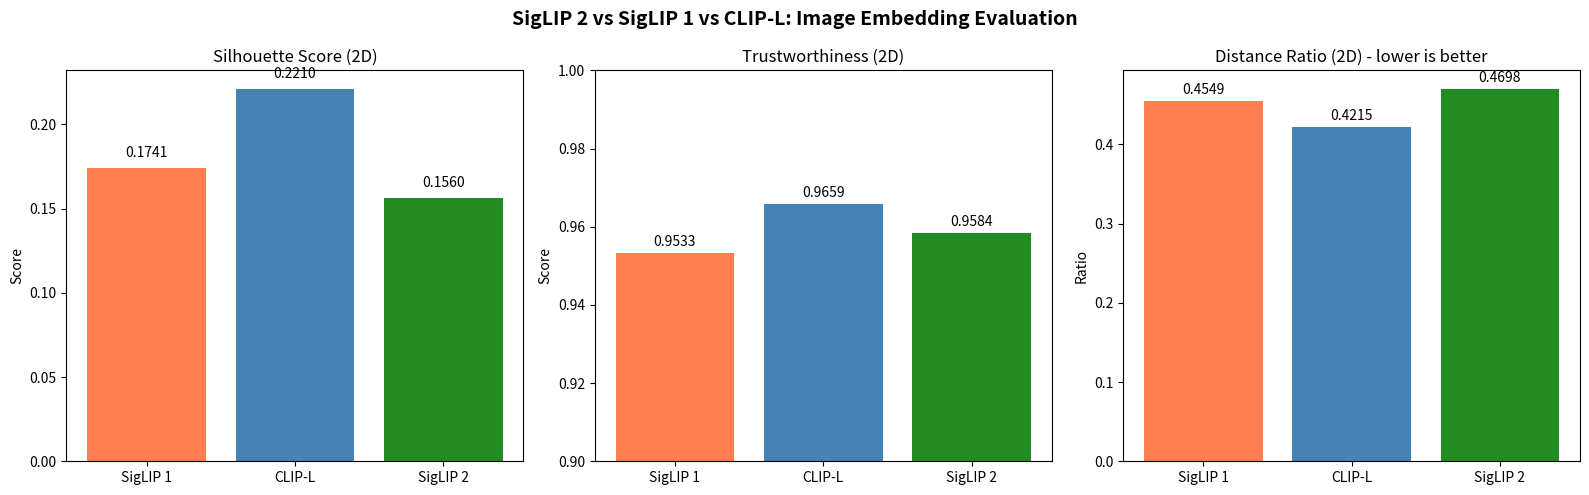

Saved: data/siglip2_vs_siglip1_vs_clipl.png


In [9]:
# 可視化: 3モデルの2D指標比較
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ["SigLIP 1", "CLIP-L", "SigLIP 2"]
colors = ["coral", "steelblue", "forestgreen"]

# シルエットスコア
ax = axes[0]
values = [comparison[m]["silhouette_2d"] for m in models]
bars = ax.bar(models, values, color=colors)
ax.set_title("Silhouette Score (2D)")
ax.set_ylabel("Score")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

# Trustworthiness
ax = axes[1]
values = [comparison[m]["trustworthiness_2d"] for m in models]
bars = ax.bar(models, values, color=colors)
ax.set_title("Trustworthiness (2D)")
ax.set_ylabel("Score")
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

# 距離比
ax = axes[2]
values = [comparison[m]["distance_ratio_2d"] for m in models]
bars = ax.bar(models, values, color=colors)
ax.set_title("Distance Ratio (2D) - lower is better")
ax.set_ylabel("Ratio")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

plt.suptitle("SigLIP 2 vs SigLIP 1 vs CLIP-L: Image Embedding Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/siglip2_vs_siglip1_vs_clipl.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/siglip2_vs_siglip1_vs_clipl.png")

## DuckDB への保存

In [10]:
# DuckDB に SigLIP 2 の埋め込みを保存
conn = duckdb.connect(str(DB_PATH))
conn.execute("INSTALL vss; LOAD vss;")

model_name = embedder.model_name

# 既存のデータがあれば削除
conn.execute("DELETE FROM image_embeddings WHERE model_name = ?", [model_name])

# 埋め込みを挿入
insert_count = 0
for idx, (image_id, embedding) in enumerate(zip(image_ids, embeddings)):
    emb_list = [float(x) for x in embedding]
    conn.execute(
        "INSERT INTO image_embeddings (id, model_name, embedding) VALUES (?, ?, ?)",
        [image_id, model_name, emb_list]
    )
    insert_count += 1

conn.commit()

# 確認
count = conn.execute(
    "SELECT COUNT(*) FROM image_embeddings WHERE model_name = ?", [model_name]
).fetchone()[0]
print(f"Stored {count} embeddings for model '{model_name}'")

# モデル別の件数
model_counts = conn.execute(
    "SELECT model_name, COUNT(*) as cnt FROM image_embeddings GROUP BY model_name ORDER BY model_name"
).fetchall()
print(f"\nAll models in DB:")
for m, c in model_counts:
    print(f"  {m}: {c}")

conn.close()

Stored 378 embeddings for model 'google/siglip2-base-patch16-224'

All models in DB:
  Xenova/siglip-base-patch16-224: 378
  Xenova/siglip-base-patch16-224-browser: 50
  Xenova/siglip-base-patch16-224-fp16: 378
  Xenova/siglip-base-patch16-224-q4: 378
  Xenova/siglip-base-patch16-224-q8: 378
  google/siglip-base-patch16-224: 378
  google/siglip2-base-patch16-224: 378
  openai/clip-vit-large-patch14: 378


## 評価結果の保存

In [11]:
# 評価結果をJSONファイルに保存
reporter = EvaluationReporter(OUTPUT_DIR)
filepath = reporter.save(metrics)
print(f"Results saved to: {filepath}")

Results saved to: ../data/evaluations/google_siglip2-base-patch16-224_2026-02-16.json


## GPUメモリのクリーンアップ

In [12]:
# モデルを削除してGPUメモリを解放
del embedder
del embeddings

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")
else:
    print("No GPU available.")

GPU memory cleared.


## まとめ・評価・考察

SigLIP 2 Base (`google/siglip2-base-patch16-224`) の画像埋め込み評価を実施した。

### 実験結果

| 指標 | SigLIP 2 Base | SigLIP 1 | CLIP-L |
|------|:---:|:---:|:---:|
| **シルエット (2D)** | 0.1560 | 0.1741 | **0.2210** |
| **Trustworthiness** | 0.9584 | 0.9533 | **0.9659** |
| **距離比** | 0.4698 | 0.4549 | **0.4215** |
| **速度 (img/s)** | **4.2** | 4.1 | 4.0 |

### 考察

1. **SigLIP 2 Base は SigLIP 1 と同程度の画像埋め込み品質**
   - シルエットスコアは SigLIP 1（0.174）よりわずかに低い（0.156）
   - Trustworthiness はわずかに高い（0.958 vs 0.953）
   - 距離比もほぼ同等（0.470 vs 0.455）
   - 結論: Base モデル同士では、画像埋め込みの品質に大きな差はない

2. **CLIP-L が画像埋め込み品質で依然として優位**
   - シルエット (0.221)、Trust (0.966)、距離比 (0.422) のすべてで CLIP-L が最良
   - ただし、CLIP-L は Large モデル（3億パラメータ）であり、Base（8600万）との直接比較は不公平
   - → Notebook 63 で SigLIP 2 Large/So400m との公平な比較を行う

3. **処理速度はほぼ同等**
   - GPU (CUDA) 環境では 3 モデルとも 4 img/s 程度で大差なし

4. **SigLIP 2 Base の位置づけ**
   - 画像埋め込み品質だけでは SigLIP 1 や CLIP-L に対する明確な優位性は見られない
   - SigLIP 2 の真の改善点はテキスト側（Gemma BPE トークナイザー、多言語対応）にある
   - → Notebook 62 でテキスト検索性能を評価する